<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# Load the data
df = pd.read_csv(r"C:\Users\lenovo-miguel\OneDrive\IBM_Data_Analytics_Coursera\survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [4]:
#let's get a specific dataset to do this analysis, excluding missing values
df_ccy = df[['ConvertedCompYearly']].dropna()
print(df_ccy.shape)
df_ccy.describe()

(23435, 1)


,ConvertedCompYearly
count,2.343500e+04
mean,8.615529e+04
std,1.867570e+05
min,1.000000e+00
25%,3.271200e+04
50%,6.500000e+04
75%,1.079715e+05
max,1.625660e+07


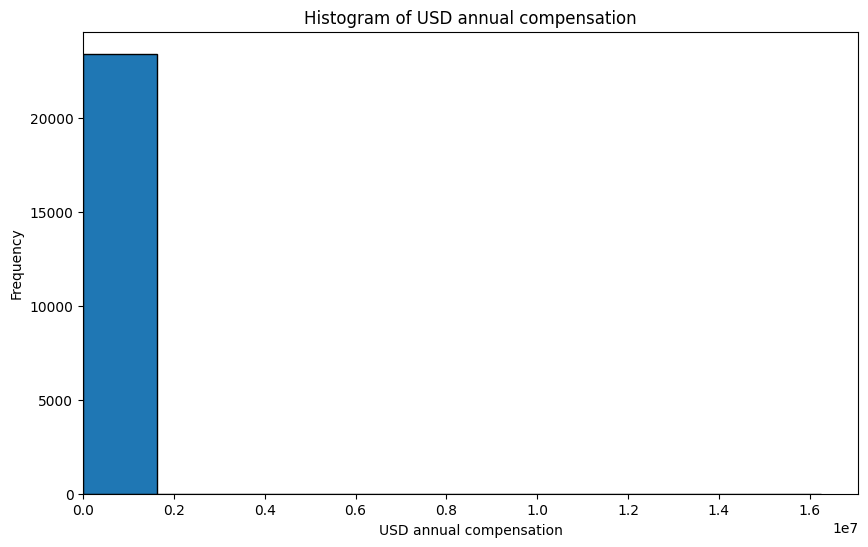

In [5]:
#let's plot the histogram
fig, ax = plt.subplots(figsize=(10, 6))
df_ccy['ConvertedCompYearly'].plot(kind='hist', ax=ax, edgecolor='black')
plt.title('Histogram of USD annual compensation')
plt.xlabel('USD annual compensation')
plt.ylabel('Frequency')
plt.xticks(rotation=0, ha='center')
plt.xlim(left=0)
plt.show()

In [6]:
#ConvertedCompYearly has outliers, let's remove them for a better analysis
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.079715e+05
q1 = 3.271200e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)
df_ccy_no_outliers = df_ccy[df_ccy['ConvertedCompYearly']<=out_upper]
print(df_ccy_no_outliers.shape)

IQR =  75259.5
Upper bound for outliers =  220860.75
Lower bound for outliers =  -80177.25
(22457, 1)


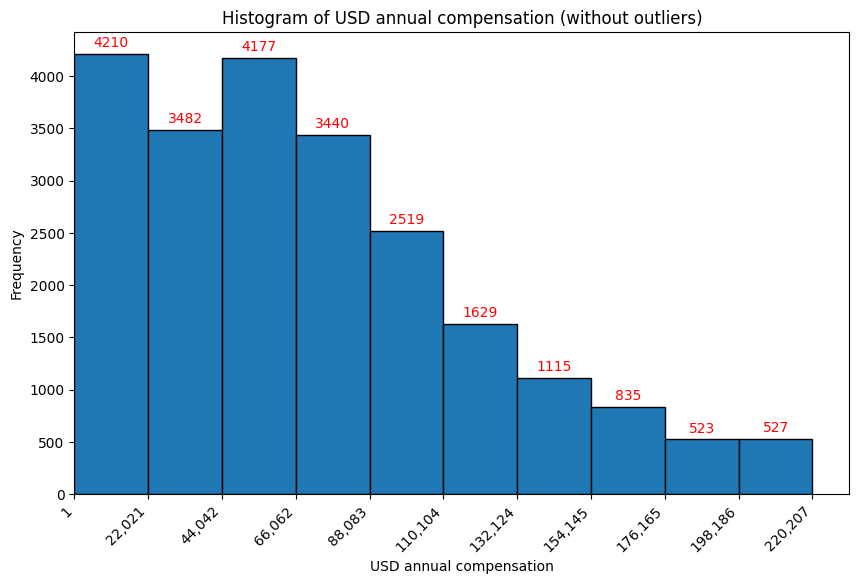

In [7]:
#let's plot the histogram without outliers and with some improvements for better visualization
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(df_ccy_no_outliers['ConvertedCompYearly'], bins=10, edgecolor='black')
plt.title('Histogram of USD annual compensation (without outliers)')
plt.xlabel('USD annual compensation')
plt.ylabel('Frequency')
plt.xticks(rotation=0, ha='center')
# Add the frequency on top of each bar
for count, patch in zip(n, patches):
    # Get the bar’s center x-position
    x = patch.get_x() + patch.get_width() / 2

    # y-position slightly above the bar
    y = count

    ax.annotate(
        str(int(count)),      # text label
        xy=(x, y),
        xytext=(0, 3),        # slight vertical offset
        textcoords='offset points',
        ha='center',
        va='bottom',
        color='red'
    )
plt.xlim(left=0)
ax.set_xticks(bins)
ax.set_xticklabels([f"{int(b):,}" for b in bins], rotation=45, ha='right')
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [8]:
#Age is a categorical variable whose values are actually  age ranges. In order to plot a box plot, we first have to convert these categorical 
#values to numbers. Let's discard the rows with 'Prefer not to say' and convert the values in the other rows to the age range mean value.
#let's get a specific dataframe for this analysis, without missing values
df_age = df[['Age']].dropna()
df_age = df_age[df_age['Age']!='Prefer not to say']
print(df_age.shape)
df_age.head()

(65115, 1)


,Age
0,Under 18 years old
1,35-44 years old
2,45-54 years old
3,18-24 years old
4,18-24 years old


In [9]:
#let's replace age ranges by range mean values
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_age['Age'] = df_age['Age'].map(numerical_ages)
df_age.rename(columns={'Age': 'Age_numeric'}, inplace=True)
df_age.head()

,Age_numeric
0,13.5
1,39.5
2,49.5
3,21.0
4,21.0


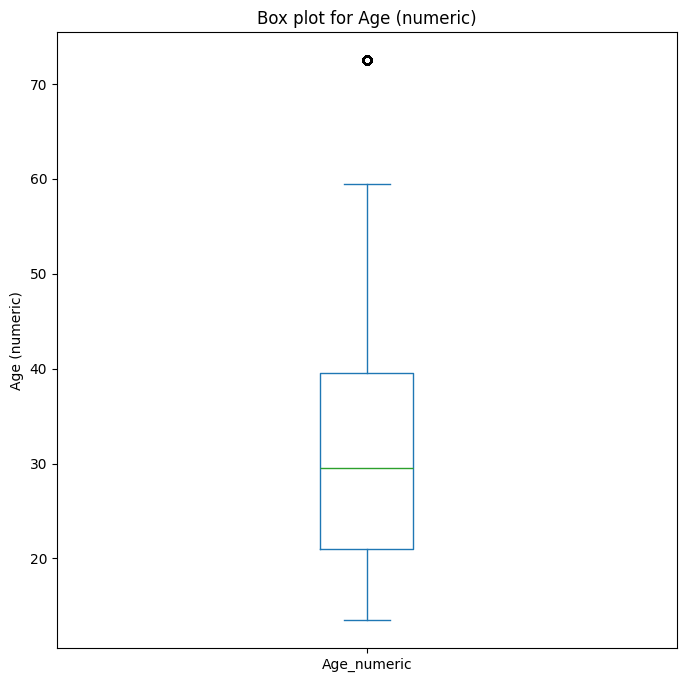

In [10]:
#let's plot the box plot for Age
df_age.plot(kind='box', figsize=(8, 8))
plt.title('Box plot for Age (numeric)')
plt.ylabel('Age (numeric)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



In [11]:
#let's get a specific dataset to do this analysis, excluding missing values and rows where Age = 'Prefer not to say'
df_age_num_ccy = df[['Age', 'ConvertedCompYearly']].dropna()
df_age_num_ccy = df_age_num_ccy[df_age_num_ccy['Age']!='Prefer not to say']
print(df_age_num_ccy.shape)
df_age_num_ccy.head()

(23426, 2)


,Age,ConvertedCompYearly
72,18-24 years old,7322.0
374,25-34 years old,30074.0
379,35-44 years old,91295.0
385,35-44 years old,53703.0
389,25-34 years old,110000.0


In [12]:
#let's replace age ranges by range mean values
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_age_num_ccy['Age'] = df_age_num_ccy['Age'].map(numerical_ages)
df_age_num_ccy.rename(columns={'Age': 'Age_numeric'}, inplace=True)
df_age_num_ccy.head()

,Age_numeric,ConvertedCompYearly
72,21.0,7322.0
374,29.5,30074.0
379,39.5,91295.0
385,39.5,53703.0
389,29.5,110000.0


In [13]:
df_age_num_ccy.describe()

,Age_numeric,ConvertedCompYearly
count,23426.000000,2.342600e+04
mean,34.215551,8.613250e+04
std,9.969475,1.867864e+05
min,13.500000,1.000000e+00
25%,29.500000,3.271200e+04
50%,29.500000,6.500000e+04
75%,39.500000,1.079370e+05
max,72.500000,1.625660e+07


In [14]:
#ConvertedCompYearly has outliers, let's remove them for a better analysis
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.079370e+05
q1 = 3.271200e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)
df_age_num_ccy_no_outliers = df_age_num_ccy[df_age_num_ccy['ConvertedCompYearly']<=out_upper]
print(df_age_num_ccy.shape)

IQR =  75225.0
Upper bound for outliers =  220774.5
Lower bound for outliers =  -80125.5
(23426, 2)


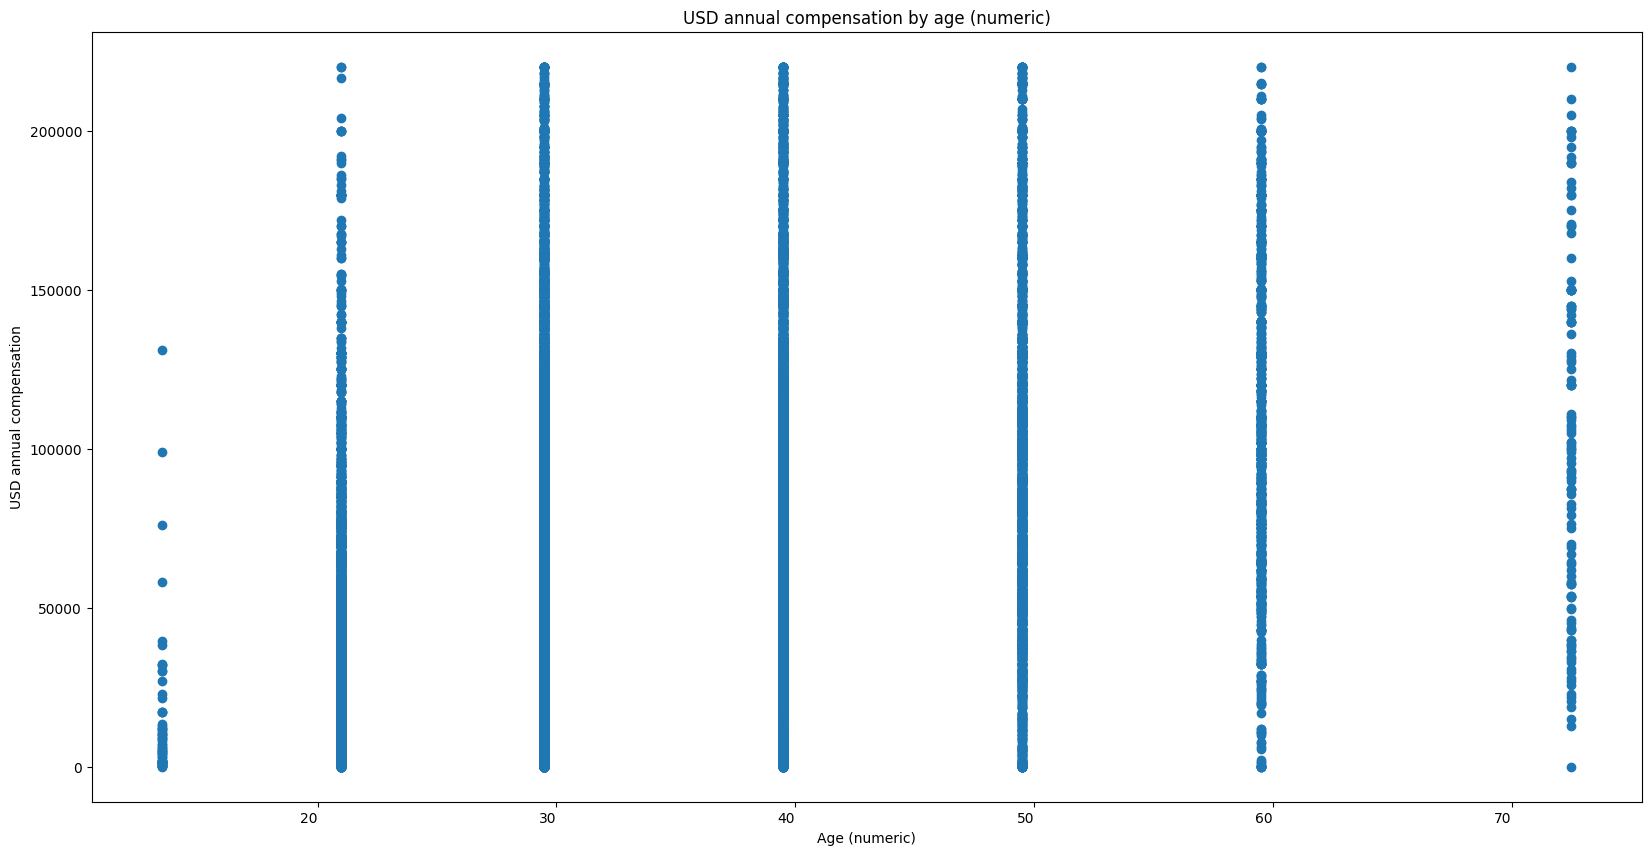

In [15]:
#let's plot the scatter plot
#scatter plot - ConvertedCompYearly by Age_numeric
plt.figure(figsize=(20, 10))
plt.scatter(df_age_num_ccy_no_outliers['Age_numeric'], df_age_num_ccy_no_outliers['ConvertedCompYearly'])
plt.xticks(rotation=0, ha='right')
plt.title('USD annual compensation by age (numeric)')
plt.xlabel('Age (numeric)')
plt.ylabel('USD annual compensation')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


In [16]:
#let's get a specific dataset for this analysis, without missing values
df_ccy_js_age = df[['ConvertedCompYearly', 'JobSat', 'Age']].dropna()
#Age is a categorical variable whose values are actually  age ranges. In order to plot  scatter plot, we first have to convert these categorical 
#values to numbers. Let's discard the rows with 'Prefer not to say' and convert the values in the other rows to the age range mean value.
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_ccy_js_age_1 = df_ccy_js_age[df_ccy_js_age['Age'] != 'Prefer not to say'].copy()
df_ccy_js_age_1.loc[:, 'Age'] = df_ccy_js_age_1['Age'].map(numerical_ages)
df_ccy_js_age_1['Age'] = df_ccy_js_age_1['Age'].astype(float)
df_ccy_js_age_1.rename(columns={'Age': 'Age_numeric'}, inplace=True)
df_ccy_js_age_1.head()

,ConvertedCompYearly,JobSat,Age_numeric
72,7322.0,10.0,21.0
379,91295.0,10.0,39.5
389,110000.0,10.0,29.5
392,161044.0,7.0,39.5
398,195000.0,5.0,49.5


###We can do a better analysis by excluding ConvertedCompYearly outliers

In [17]:
df_ccy_js_age_1['ConvertedCompYearly'].describe()

count    1.606700e+04
mean     8.591619e+04
std      1.722711e+05
min      1.000000e+00
25%      3.356800e+04
50%      6.590700e+04
75%      1.080380e+05
max      1.381802e+07
Name: ConvertedCompYearly, dtype: float64

In [18]:
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1), and remove outliers from dataframe
q3 = 1.080380e+05
q1 = 3.356800e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)
df_ccy_js_age_1_no_outliers = df_ccy_js_age_1[df_ccy_js_age_1['ConvertedCompYearly']<=out_upper]
df_ccy_js_age_1_no_outliers.shape

IQR =  74470.0
Upper bound for outliers =  219743.0
Lower bound for outliers =  -78137.0


(15391, 3)

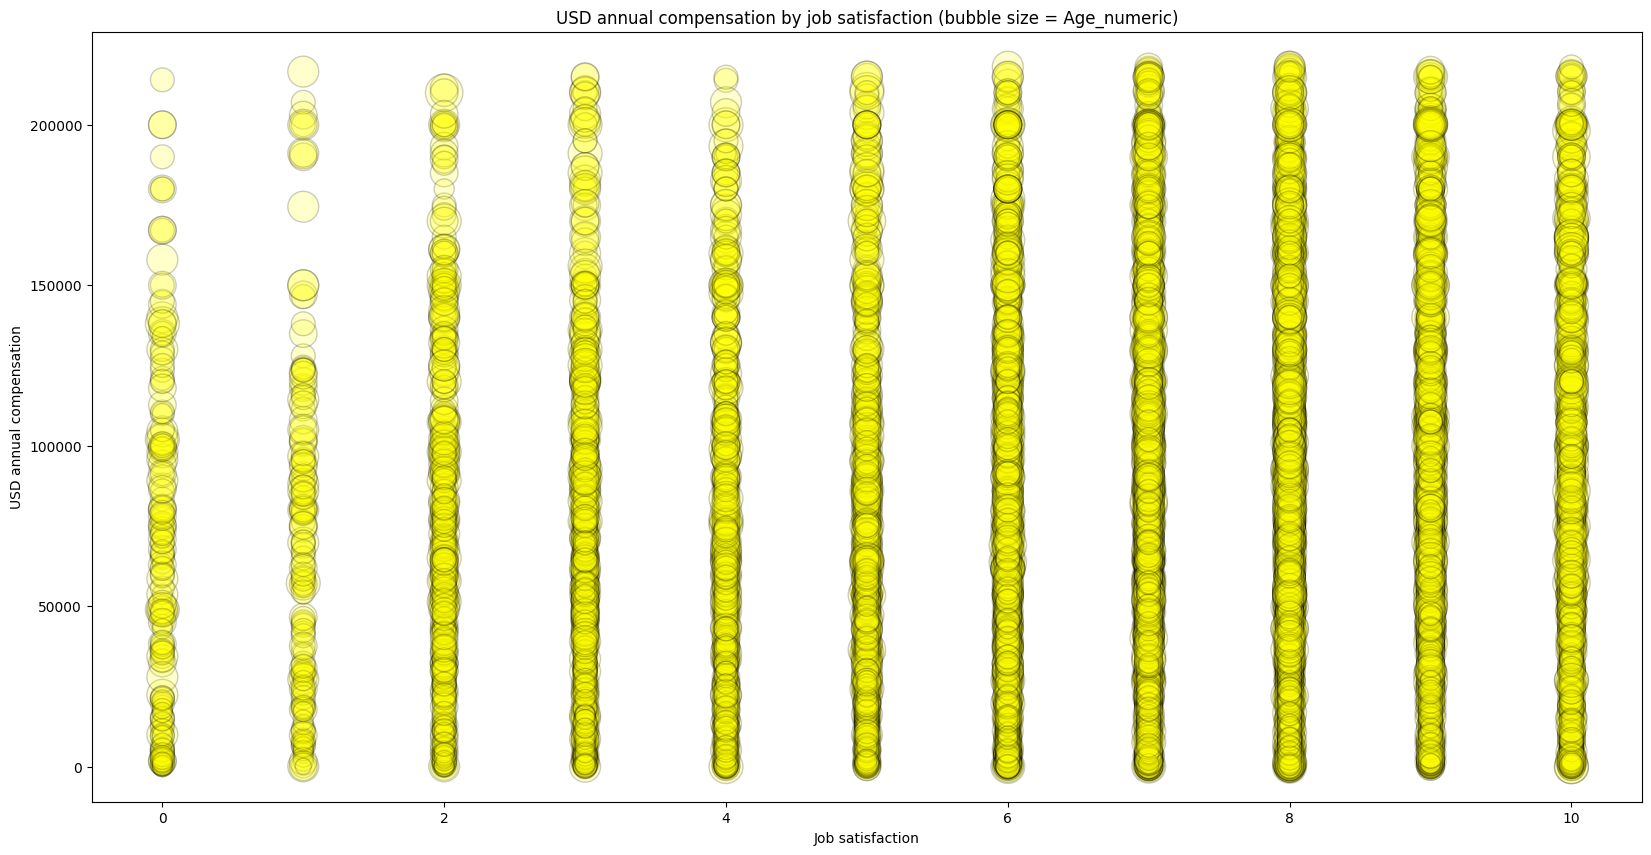

In [19]:
#let's plot the bubble chart
plt.figure(figsize=(20, 10))

# Scatter plot
plt.scatter(
    x=df_ccy_js_age_1_no_outliers['JobSat'],
    y=df_ccy_js_age_1_no_outliers['ConvertedCompYearly'],
    s=df_ccy_js_age_1_no_outliers['Age_numeric'] *10,
    alpha=0.2,
    color='yellow',
    edgecolors='black')

plt.title('USD annual compensation by job satisfaction (bubble size = Age_numeric)')
plt.xlabel('Job satisfaction')
plt.ylabel('USD annual compensation')
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



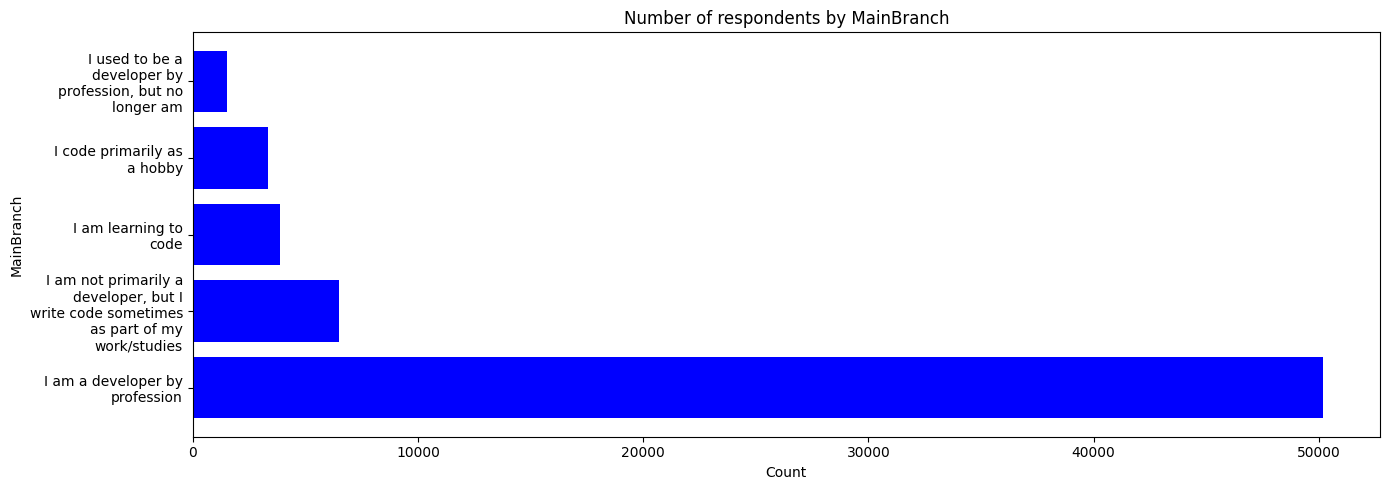

In [20]:
#let's get a specific dataframe to do this analysis, without missing values
df_mb = df[['MainBranch']].dropna()

#visualization for MainBranch using bar plot

counts = df_mb['MainBranch'].value_counts()

# Wrap the labels
labels = [textwrap.fill(label, 20) for label in counts.index]  # 20 = max chars per line

#plot the chart
plt.figure(figsize=(14, 5))
plt.barh(labels, counts, color='blue')

plt.title('Number of respondents by MainBranch')
plt.ylabel('MainBranch')
plt.xlabel('Count')

plt.yticks(rotation=0)  
plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



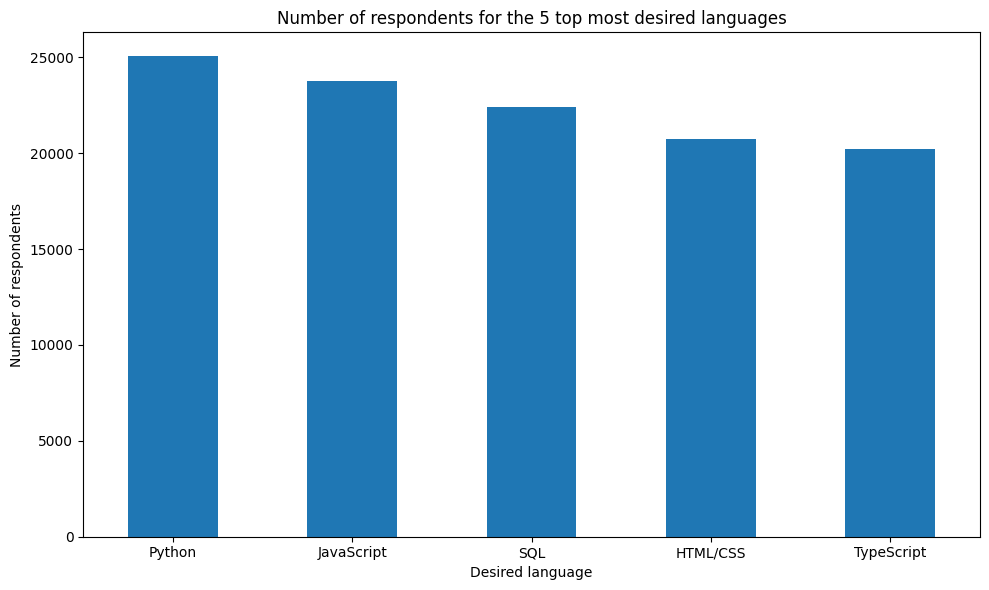

In [21]:
#let's create a new dataset to do this analysis, without missing values
df_languages = df[['LanguageWantToWorkWith']].dropna()
#let's expand the dataframe by creating one row for each language when we have multiple options in LanguageWantToWorkWith
df_languages['DesiredLanguage'] = df_languages['LanguageWantToWorkWith'].str.split(';') # create a new column with a list of all options of LanguageWantToWorkWith
df_languages = df_languages.explode('DesiredLanguage') # replicate rows with more than one language in this new column
#let's get the distribution for the 5 top desired languages
languages_top5 = df_languages['DesiredLanguage'].value_counts().head()
#lets plot the chart
plt.figure(figsize=(10, 6))
languages_top5.plot.bar()

plt.title('Number of respondents for the 5 top most desired languages')
plt.ylabel('Number of respondents')
plt.xlabel('Desired language')

plt.xticks(rotation=0)  
plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


(29424, 3)


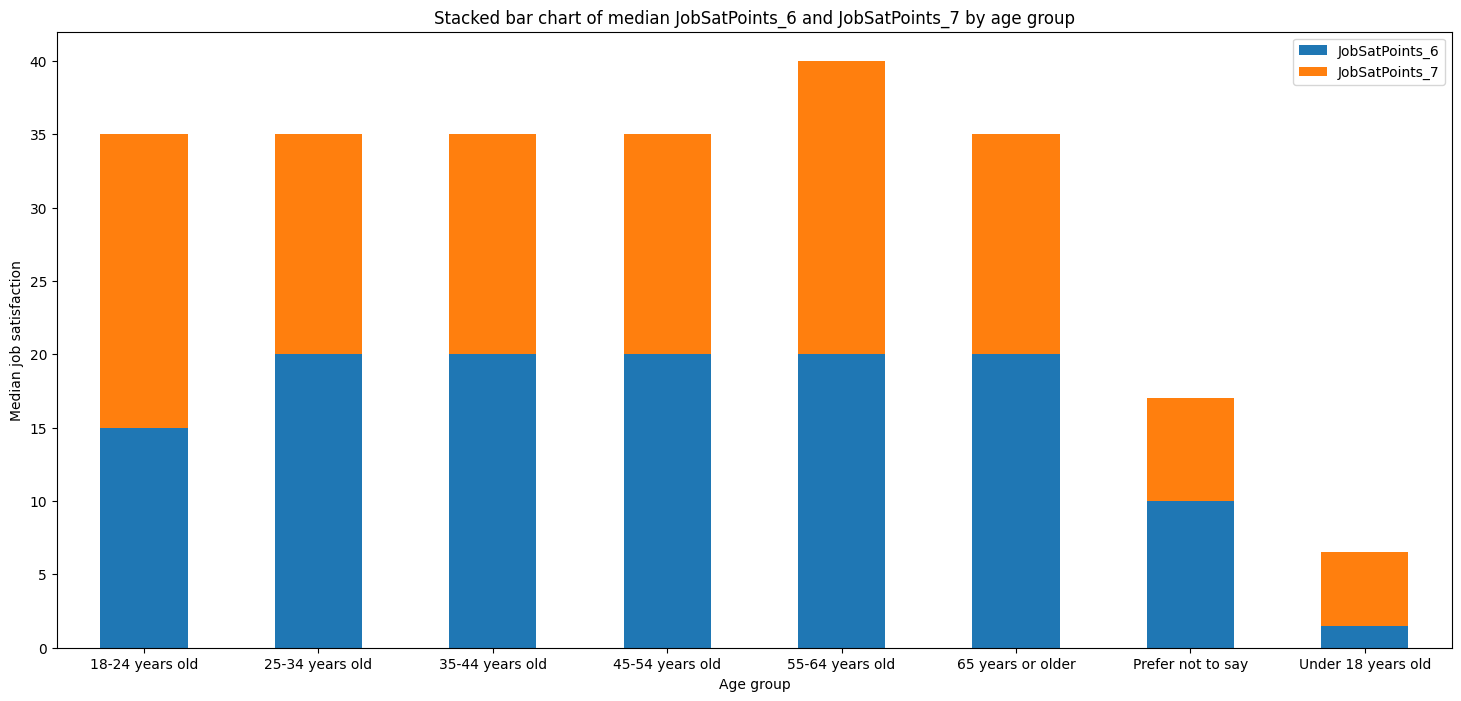

In [22]:
#let's get a specific dataset for this analysis, without missing values
df_age_js = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()
print(df_age_js.shape)
#let's group by age group getting the median of the job satisfaction columns
df_age_js_grouped = df_age_js.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
#let's plot the stacked bar chart
fig, ax = plt.subplots(figsize=(18, 8))
df_age_js_grouped.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_ylabel('Median job satisfaction')
ax.set_xlabel('Age group')
plt.title('Stacked bar chart of median JobSatPoints_6 and JobSatPoints_7 by age group')
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



(50254, 1)


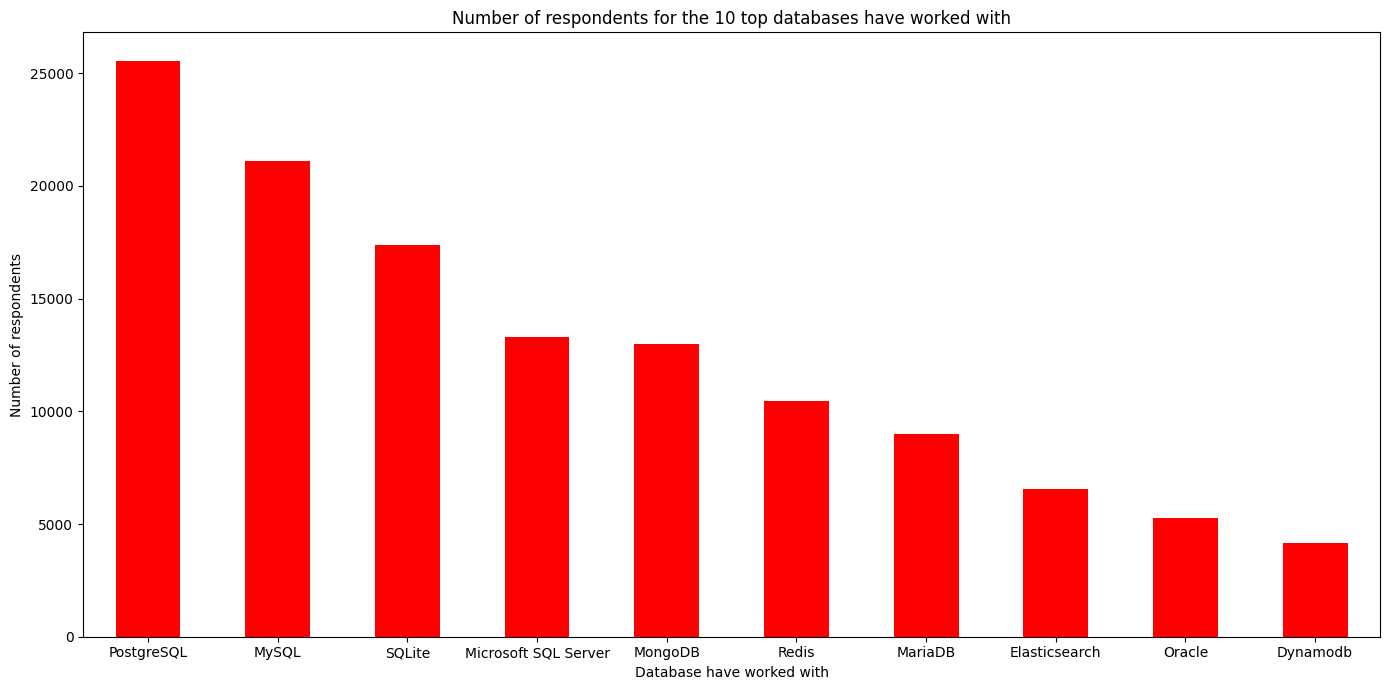

In [23]:
#let's get a specific dataset for this analysis, without missing values
df_dbhww= df[['DatabaseHaveWorkedWith']].dropna()
print(df_dbhww.shape)
#let's expand the dataframe by creating one row for each database when we have multiple options in DatabaseHaveWorkedWith
df_dbhww['Database'] = df_dbhww['DatabaseHaveWorkedWith'].str.split(';') # create a new column with a list of all database options
df_dbhww = df_dbhww.explode('Database') # replicate rows with more than one database in this new column
#let's get the top 10 most desired databases and plot the chart
db_top10 = df_dbhww['Database'].value_counts().head(10)
#lets plot the chart
plt.figure(figsize=(14, 7))
db_top10.plot.bar(color='red')

plt.title('Number of respondents for the 10 top databases have worked with')
plt.ylabel('Number of respondents')
plt.xlabel('Database have worked with')

plt.xticks(rotation=0)  
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



In [24]:
#let's get a specific dataset for this analysis, without missing values
df_age_ccy = df[['Age', 'ConvertedCompYearly']].dropna()
df_age_ccy.head()

,Age,ConvertedCompYearly
72,18-24 years old,7322.0
374,25-34 years old,30074.0
379,35-44 years old,91295.0
385,35-44 years old,53703.0
389,25-34 years old,110000.0


###We can do a better analysis by excluding ConvertedCompYearly outliers

In [25]:
df_age_ccy['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [26]:
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1), and remove outliers from dataframe
q3 = 1.079715e+05
q1 = 3.271200e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)
df_age_ccy_no_outliers = df_age_ccy[df_age_ccy['ConvertedCompYearly']<=out_upper]

IQR =  75259.5
Upper bound for outliers =  220860.75
Lower bound for outliers =  -80177.25


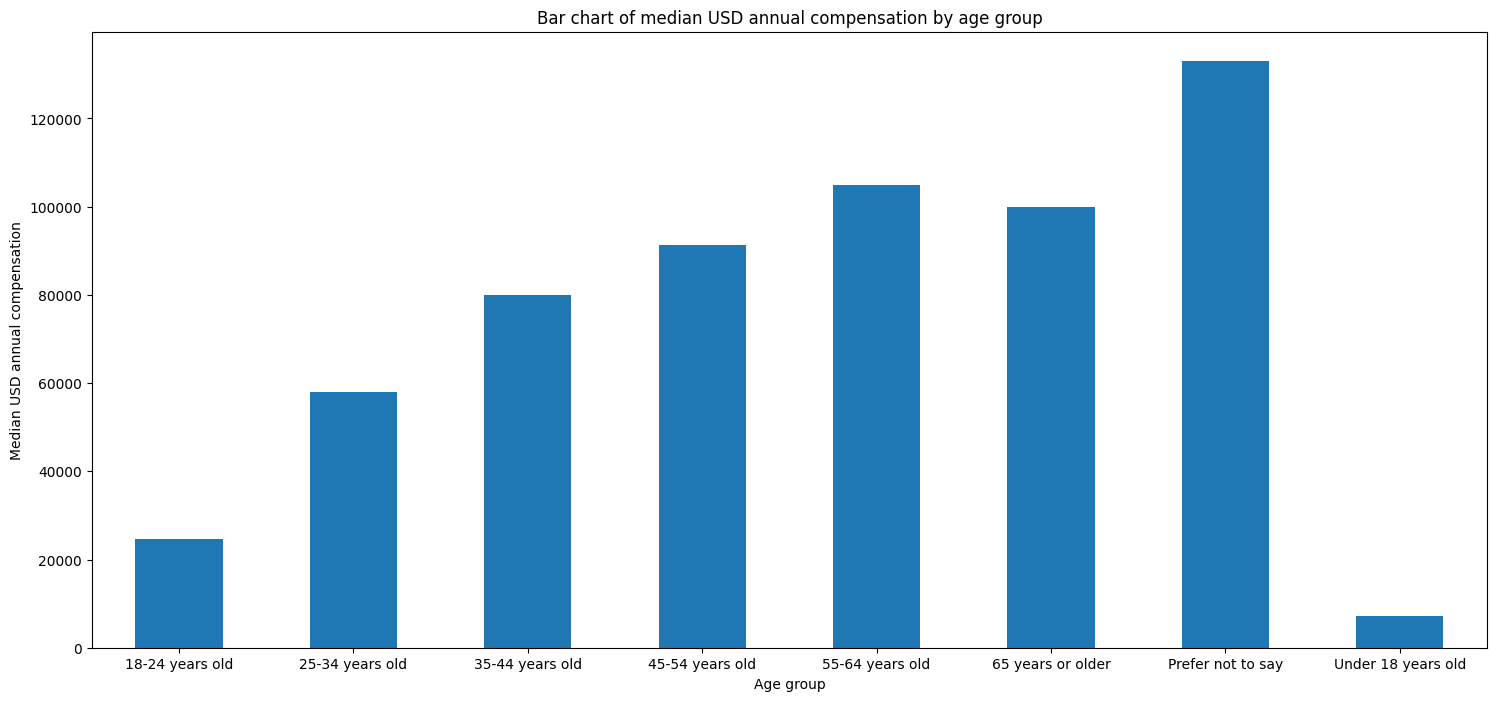

In [27]:
#let's group by age group getting the median of the annual compensation column
df_age_ccy_no_outliers_grouped = df_age_ccy_no_outliers.groupby('Age')['ConvertedCompYearly'].median()
#let's plot the bar chart
fig, ax = plt.subplots(figsize=(18, 8))
df_age_ccy_no_outliers_grouped.plot(kind='bar', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_ylabel('Median USD annual compensation')
ax.set_xlabel('Age group')
plt.title('Bar chart of median USD annual compensation by age group')
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



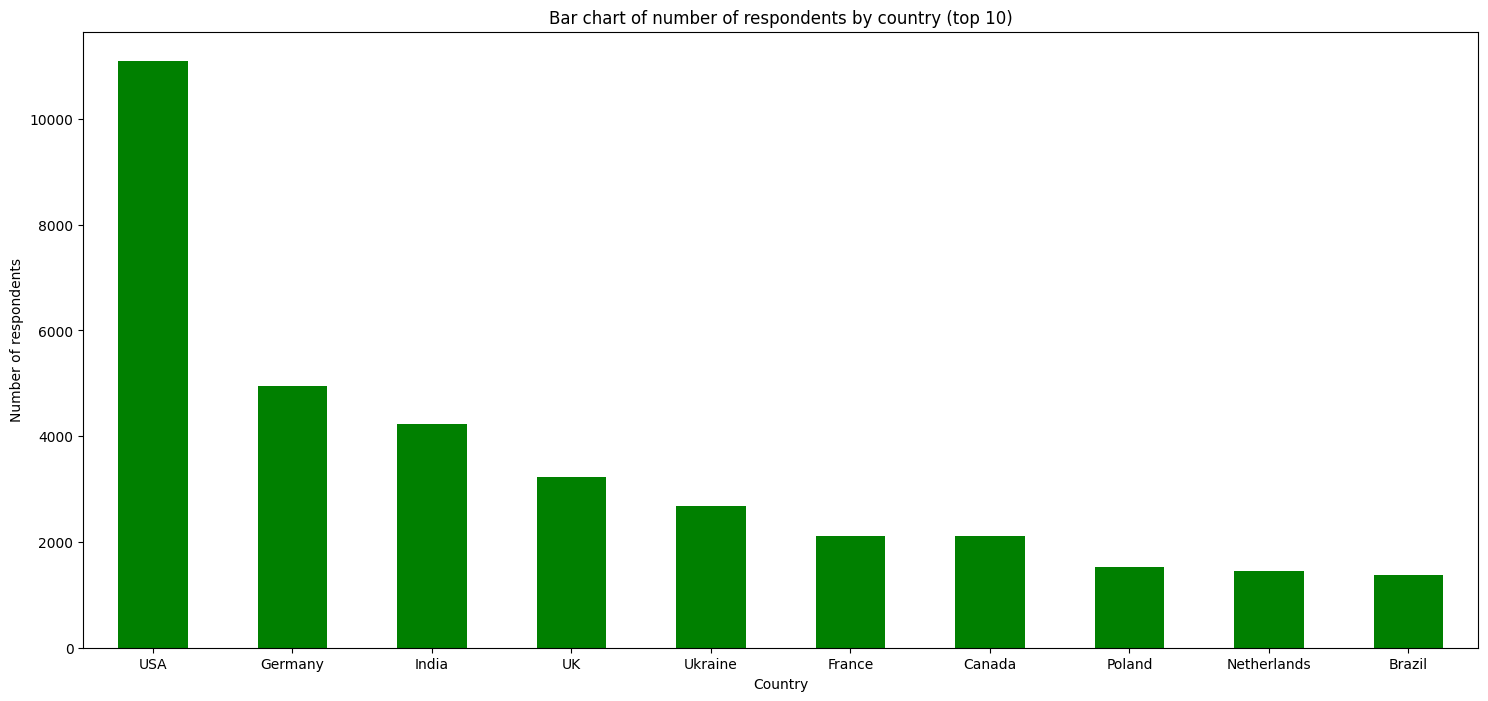

In [28]:
#let's get a specific dataframe for this analysis, without missing values
df_country = df[['Country']].dropna()
#let's get the number of respondents by the top 10 countries
df_country_no_resp_top10 = df_country['Country'].value_counts().head(10)
#let's rename conuntry names which are too long
df_country_no_resp_top10.rename(index={'United States of America': 'USA', 'United Kingdom of Great Britain and Northern Ireland': 'UK'}, inplace=True)
#let's plot the bar chart
fig, ax = plt.subplots(figsize=(18, 8))
df_country_no_resp_top10.plot(kind='bar', ax=ax, color='green')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_ylabel('Number of respondents')
ax.set_xlabel('Country')
plt.title('Bar chart of number of respondents by country (top 10)')
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
